In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv('/content/customer_satisfaction_analysis.csv')
data.head()

,Customer_ID,Year,Customer_Satisfaction_Score,Net_Promoter_Score,Customer_Feedback_Volume,Service_Interaction_Quality,Response_Time_Minutes,Resolution_Time_Minutes,Repeat_Purchase_Rate,Customer_Loyalty_Metric,Customer_Age,Customer_Gender,Customer_Income,Customer_Region,Issue_Category
0,1.0,2011.0,7.0,NaN,3.0,NaN,15.0,53.0,91.0,5.0,NaN,Other,NaN,Midwest,Billing
1,2.0,2019.0,NaN,0.0,6.0,1.0,6.0,569.0,61.0,3.0,35.0,Female,60000.0,Midwest,Technical
2,3.0,2015.0,NaN,-17.0,8.0,2.0,54.0,91.0,87.0,10.0,47.0,Other,90000.0,West,Service
3,4.0,2012.0,5.0,60.0,7.0,4.0,45.0,520.0,79.0,2.0,49.0,Male,40000.0,NaN,Technical
4,5.0,2011.0,1.0,-73.0,NaN,1.0,NaN,302.0,NaN,1.0,57.0,Female,60000.0,South,Billing


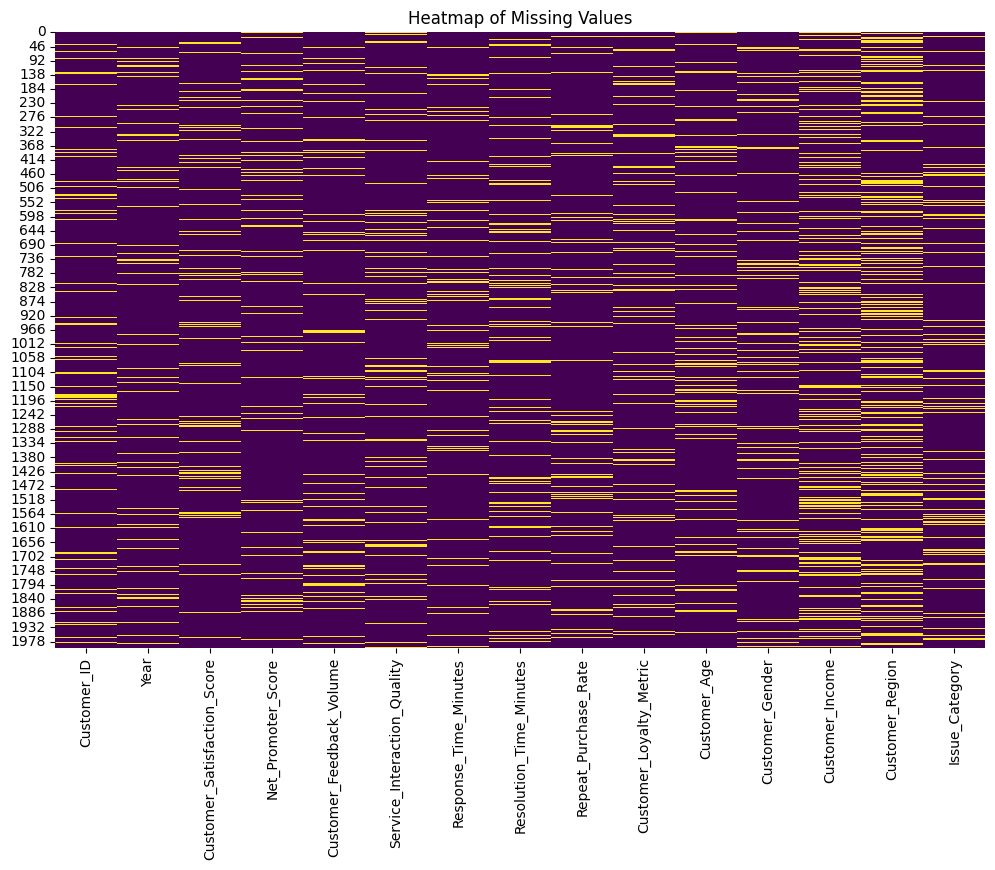

In [4]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.show()

In [5]:
categorical_columns = ['Customer_Gender', 'Customer_Region', 'Issue_Category']
numerical_columns = ['Year', 'Customer_Satisfaction_Score', 'Net_Promoter_Score', 'Customer_Feedback_Volume',
                     'Service_Interaction_Quality', 'Response_Time_Minutes', 'Resolution_Time_Minutes',
                     'Repeat_Purchase_Rate', 'Customer_Loyalty_Metric', 'Customer_Age', 'Customer_Income']

In [6]:
def impute_missing_values(df):
    for column in categorical_columns:
        mode_value = df[column].mode().iloc[0]
        df[column].fillna(mode_value, inplace=True)

    for column in numerical_columns:
        median_value = df[column].median()
        df[column].fillna(median_value, inplace=True)

    if 'Customer_ID' in df.columns:
        df['Customer_ID'] = df['Customer_ID'].fillna(df.index.to_series().apply(lambda x: x + 1))

    return df

df=impute_missing_values(data)
missing_values_after_imputation = data.isnull().sum()
missing_values_after_imputation

Customer_ID                    0
Year                           0
Customer_Satisfaction_Score    0
Net_Promoter_Score             0
Customer_Feedback_Volume       0
Service_Interaction_Quality    0
Response_Time_Minutes          0
Resolution_Time_Minutes        0
Repeat_Purchase_Rate           0
Customer_Loyalty_Metric        0
Customer_Age                   0
Customer_Gender                0
Customer_Income                0
Customer_Region                0
Issue_Category                 0
dtype: int64

In [7]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

for col in numerical_columns:
    df = remove_outliers(df, col)

In [8]:
df[numerical_columns] = df[numerical_columns].round(2)

In [9]:
cleaned_file_path = 'modified_customer_satisfaction_analysis.csv'
df.to_csv(cleaned_file_path, index=False)

In [10]:
summary_statistics = df[numerical_columns].describe()
frequency_table = df[categorical_columns].apply(pd.Series.value_counts)

In [11]:
summary_statistics

,Year,Customer_Satisfaction_Score,Net_Promoter_Score,Customer_Feedback_Volume,Service_Interaction_Quality,Response_Time_Minutes,Resolution_Time_Minutes,Repeat_Purchase_Rate,Customer_Loyalty_Metric,Customer_Age,Customer_Income
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000
mean,2013.242000,5.445000,3.888500,4.94350,2.919000,31.768500,316.922500,64.259000,5.393500,47.945500,59805.00000
std,5.011087,2.712131,55.897722,2.44751,1.369079,14.994843,159.536301,19.611839,2.784697,16.956954,17806.47383
min,2005.000000,1.000000,-100.000000,1.00000,1.000000,5.000000,30.000000,30.000000,1.000000,18.000000,30000.00000
25%,2009.000000,3.000000,-40.250000,3.00000,2.000000,20.000000,188.000000,48.750000,3.000000,34.000000,50000.00000
50%,2013.000000,5.000000,6.000000,5.00000,3.000000,31.000000,322.000000,63.000000,5.000000,48.000000,60000.00000
75%,2017.000000,8.000000,50.000000,7.00000,4.000000,44.000000,448.000000,80.250000,8.000000,62.000000,70000.00000
max,2022.000000,10.000000,100.000000,9.00000,5.000000,59.000000,599.000000,100.000000,10.000000,79.000000,90000.00000


In [12]:
frequency_table

,Customer_Gender,Customer_Region,Issue_Category
Billing,NaN,NaN,576.0
East,NaN,294.0,NaN
Female,833.0,NaN,NaN
Male,584.0,NaN,NaN
Midwest,NaN,825.0,NaN
North,NaN,291.0,NaN
Other,583.0,NaN,NaN
Service,NaN,NaN,853.0
South,NaN,321.0,NaN
Technical,NaN,NaN,571.0
